<a href="https://colab.research.google.com/github/ejaila/TelecomX_Latam_Parte-2/blob/main/TelecomX_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

In [2]:
# 1. Cargar los datos
df = pd.read_csv('/content/drive/MyDrive/datos_tratados.csv')
df.head()

,CustomerID,Churn,Gender,SeniorCitizen,Partner,Dependents,Tenure,PhoneService,MultipleLines,InternetService,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,ChargesDaily,ChargesMonthly,ChargesTotal
0,0002-ORFBO,No,Female,No,Yes,Yes,9,Yes,No,DSL,...,No,Yes,Yes,No,One year,Yes,Mailed check,2.19,65.6,593.30
1,0003-MKNFE,No,Male,No,No,No,9,Yes,Yes,DSL,...,No,No,No,Yes,Month-to-month,No,Mailed check,2.00,59.9,542.40
2,0004-TLHLJ,Yes,Male,No,No,No,4,Yes,No,Fiber optic,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,2.46,73.9,280.85
3,0011-IGKFF,Yes,Male,Yes,Yes,No,13,Yes,No,Fiber optic,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,3.27,98.0,1237.85
4,0013-EXCHZ,Yes,Female,Yes,Yes,No,3,Yes,No,Fiber optic,...,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,2.80,83.9,267.40


In [3]:
df.columns

Index(['CustomerID', 'Churn', 'Gender', 'SeniorCitizen', 'Partner',
       'Dependents', 'Tenure', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'ChargesDaily', 'ChargesMonthly',
       'ChargesTotal'],
      dtype='object')

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   CustomerID        7043 non-null   object 
 1   Churn             7043 non-null   object 
 2   Gender            7043 non-null   object 
 3   SeniorCitizen     7043 non-null   object 
 4   Partner           7043 non-null   object 
 5   Dependents        7043 non-null   object 
 6   Tenure            7043 non-null   int64  
 7   PhoneService      7043 non-null   object 
 8   MultipleLines     7043 non-null   object 
 9   InternetService   7043 non-null   object 
 10  OnlineSecurity    7043 non-null   object 
 11  OnlineBackup      7043 non-null   object 
 12  DeviceProtection  7043 non-null   object 
 13  TechSupport       7043 non-null   object 
 14  StreamingTV       7043 non-null   object 
 15  StreamingMovies   7043 non-null   object 
 16  Contract          7043 non-null   object 


In [5]:
# 2. Eliminación de columnas no determinantes
df = df.drop(columns=['CustomerID', 'ChargesDaily', 'ChargesTotal'], errors='ignore')

In [6]:
# Verificamos los valores nulos
df.isnull().sum()

,0
Churn,0
Gender,0
SeniorCitizen,0
Partner,0
Dependents,0
Tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [7]:
# 3. Unificación de categorías 'No internet service' a 'No'
columnas_fix = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                     'TechSupport', 'StreamingTV', 'StreamingMovies']
for col in columnas_fix:
    df[col] = df[col].replace({'No internet service': 'No'})

In [8]:
# 4. Codificación de la variable objetivo (Churn)
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})
df_numeric = df.select_dtypes(include=["int64", "float64"])
df_numeric['Churn'] = df["Churn"].map({"Yes": 1, "No": 0})
corr_matrix = df_numeric.corr()

#Visualizamos
plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlación - Variables numericas')
plt.show()

In [9]:
categorical_cols = df.select_dtypes(include=["object"]).columns
categorical_cols = categorical_cols.drop("Churn")


In [14]:
# Tabla de proporción por categoria
for col in categorical_cols:
    print(f"\n📌 Analisis de variable: {col}")
    display(pd.crosstab(df[col], df["Churn"], normalize="index") * 100)



📌 Analisis de variable: Gender


Churn,No,Yes
Gender,,
Female,73.079128,26.920872
Male,73.839662,26.160338



📌 Analisis de variable: SeniorCitizen


Churn,No,Yes
SeniorCitizen,,
No,76.393832,23.606168
Yes,58.318739,41.681261



📌 Analisis de variable: Partner


...

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858



📌 Analisis de variable: PaperlessBilling


Churn,No,Yes
PaperlessBilling,,
No,83.669916,16.330084
Yes,66.434908,33.565092



📌 Analisis de variable: PaymentMethod


Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.290155,16.709845
Credit card (automatic),84.756899,15.243101
Electronic check,54.714588,45.285412
Mailed check,80.893300,19.106700


In [10]:

from sklearn.feature_selection import chi2

# Crea copia
df_rank = df.copy()

# Convertir Churn para binario
df_rank["Churn"] = df_rank["Churn"].map({"Yes": 1, "No": 0})

# Separar variables categóricas
categorical_cols = df_rank.select_dtypes(include=["object"]).columns

# Aplicar Label Encoding temporario
le = LabelEncoder()
for col in categorical_cols:
    df_rank[col] = le.fit_transform(df_rank[col])

# Separar X e y
X_cat = df_rank[categorical_cols]
y = df_rank["Churn"]

# Aplicar teste Qui-cuadrado
chi_scores, p_values = chi2(X_cat, y)

# Criar DataFrame com ranking
chi_df = pd.DataFrame({
    "Variable": categorical_cols,
    "Chi2 Score": chi_scores,
    "p-value": p_values
})

# Ordenar por importancia
chi_df = chi_df.sort_values(by="Chi2 Score", ascending=False)

chi_df

,Variable,Chi2 Score,p-value
13,Contract,1115.780167,1.227941e-244
7,OnlineSecurity,147.295858,6.761696e-34
10,TechSupport,135.559783,2.490549e-31
1,SeniorCitizen,134.351545,4.576959e-31
3,Dependents,133.036443,8.876729e-31
14,PaperlessBilling,105.680863,8.661987e-25
2,Partner,82.412083,1.104764e-19
15,PaymentMethod,58.492250,2.040933e-14
8,OnlineBackup,31.217694,2.306541e-08
9,DeviceProtection,20.226662,6.878750e-06


In [11]:
significant_vars = chi_df[chi_df["p-value"] < 0.05]

print("\n✅ Variables significativas (p < 0.05):")
display(significant_vars)


✅ Variables significativas (p < 0.05):


,Variable,Chi2 Score,p-value
13,Contract,1115.780167,1.227941e-244
7,OnlineSecurity,147.295858,6.761696e-34
10,TechSupport,135.559783,2.490549e-31
1,SeniorCitizen,134.351545,4.576959e-31
3,Dependents,133.036443,8.876729e-31
14,PaperlessBilling,105.680863,8.661987e-25
2,Partner,82.412083,1.104764e-19
15,PaymentMethod,58.492250,2.040933e-14
8,OnlineBackup,31.217694,2.306541e-08
9,DeviceProtection,20.226662,6.878750e-06


In [17]:
#df = df.drop(columns=["Gender", "PhoneService"])

Distribución de la variable objetivo (Churn):
Churn
0    73.463013
1    26.536987
Name: proportion, dtype: float64


/tmp/ipykernel_403/3405294244.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=correlaciones.values, y=correlaciones.index, palette='viridis')


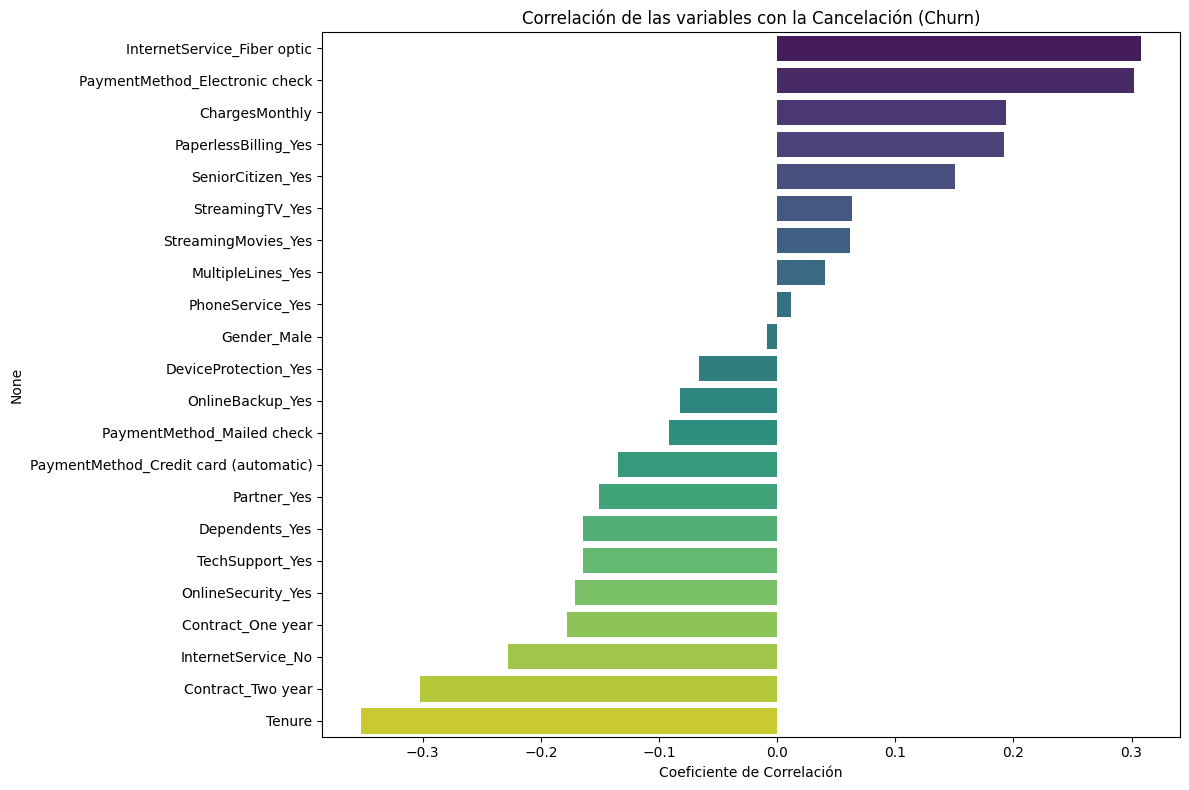

In [10]:

# 5. Verificación de desbalanceo de clase
print("Distribución de la variable objetivo (Churn):")
print(df['Churn'].value_counts(normalize=True) * 100)

# 6. Codificación de variables categóricas (One-Hot Encoding)
# Separamos variables numéricas y categóricas
vars_numericas = ['Tenure', 'ChargesMonthly']
vars_categoricas = [col for col in df.columns if col not in vars_numericas + ['Churn']]

df_encoded = pd.get_dummies(df, columns=vars_categoricas, drop_first=True)

# 7. Matriz de Correlación
plt.figure(figsize=(12, 8))

# Correlación de todas las variables con Churn
correlaciones = df_encoded.corr()['Churn'].sort_values(ascending=False)
correlaciones = correlaciones.drop('Churn')

sns.barplot(x=correlaciones.values, y=correlaciones.index, palette='viridis')
plt.title('Correlación de las variables con la Cancelación (Churn)')
plt.xlabel('Coeficiente de Correlación')
plt.tight_layout()
plt.show()

#Entrenamiento de Modelos y Evaluación

In [11]:
# 1. Separación de datos (Train / Test)
X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


In [12]:
# 2. Normalización de variables numéricas
scaler = StandardScaler()
X_train[vars_numericas] = scaler.fit_transform(X_train[vars_numericas])
X_test[vars_numericas] = scaler.transform(X_test[vars_numericas])


In [13]:
# 3. Entrenamiento: Regresión Logística
log_model = LogisticRegression(class_weight='balanced', random_state=42)
log_model.fit(X_train, y_train)
y_pred_log = log_model.predict(X_test)

In [14]:
# 4. Entrenamiento: Random Forest
rf_model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)


In [15]:
# 5. Evaluación
print("\n--- Rendimiento Regresión Logística ---")
print(classification_report(y_test, y_pred_log))

print("\n--- Rendimiento Random Forest ---")
print(classification_report(y_test, y_pred_rf))



--- Rendimiento Regresión Logística ---
              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1035
           1       0.51      0.78      0.62       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409


--- Rendimiento Random Forest ---
              precision    recall  f1-score   support

           0       0.82      0.90      0.86      1035
           1       0.61      0.45      0.52       374

    accuracy                           0.78      1409
   macro avg       0.72      0.67      0.69      1409
weighted avg       0.76      0.78      0.77      1409



In [16]:
# 6. Extracción de Importancia de Variables (Random Forest)
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]


/tmp/ipykernel_403/4122777022.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances[indices][:10], y=X.columns[indices][:10], palette='magma')


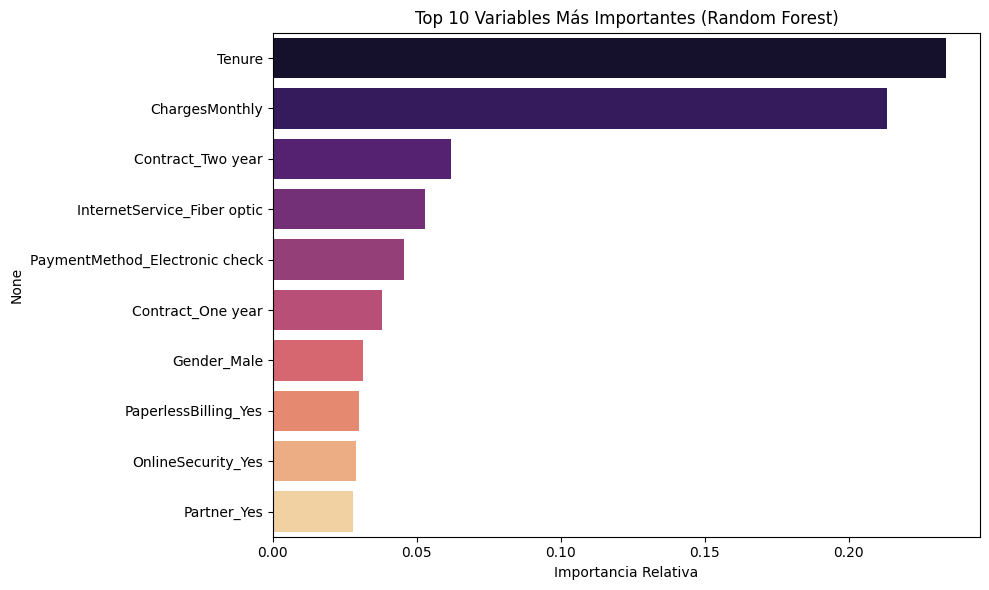

In [17]:
plt.figure(figsize=(10, 6))
sns.barplot(x=importances[indices][:10], y=X.columns[indices][:10], palette='magma')
plt.title('Top 10 Variables Más Importantes (Random Forest)')
plt.xlabel('Importancia Relativa')
plt.tight_layout()
plt.show()

# Conclusión Estratégica e Interpretación de Resultados

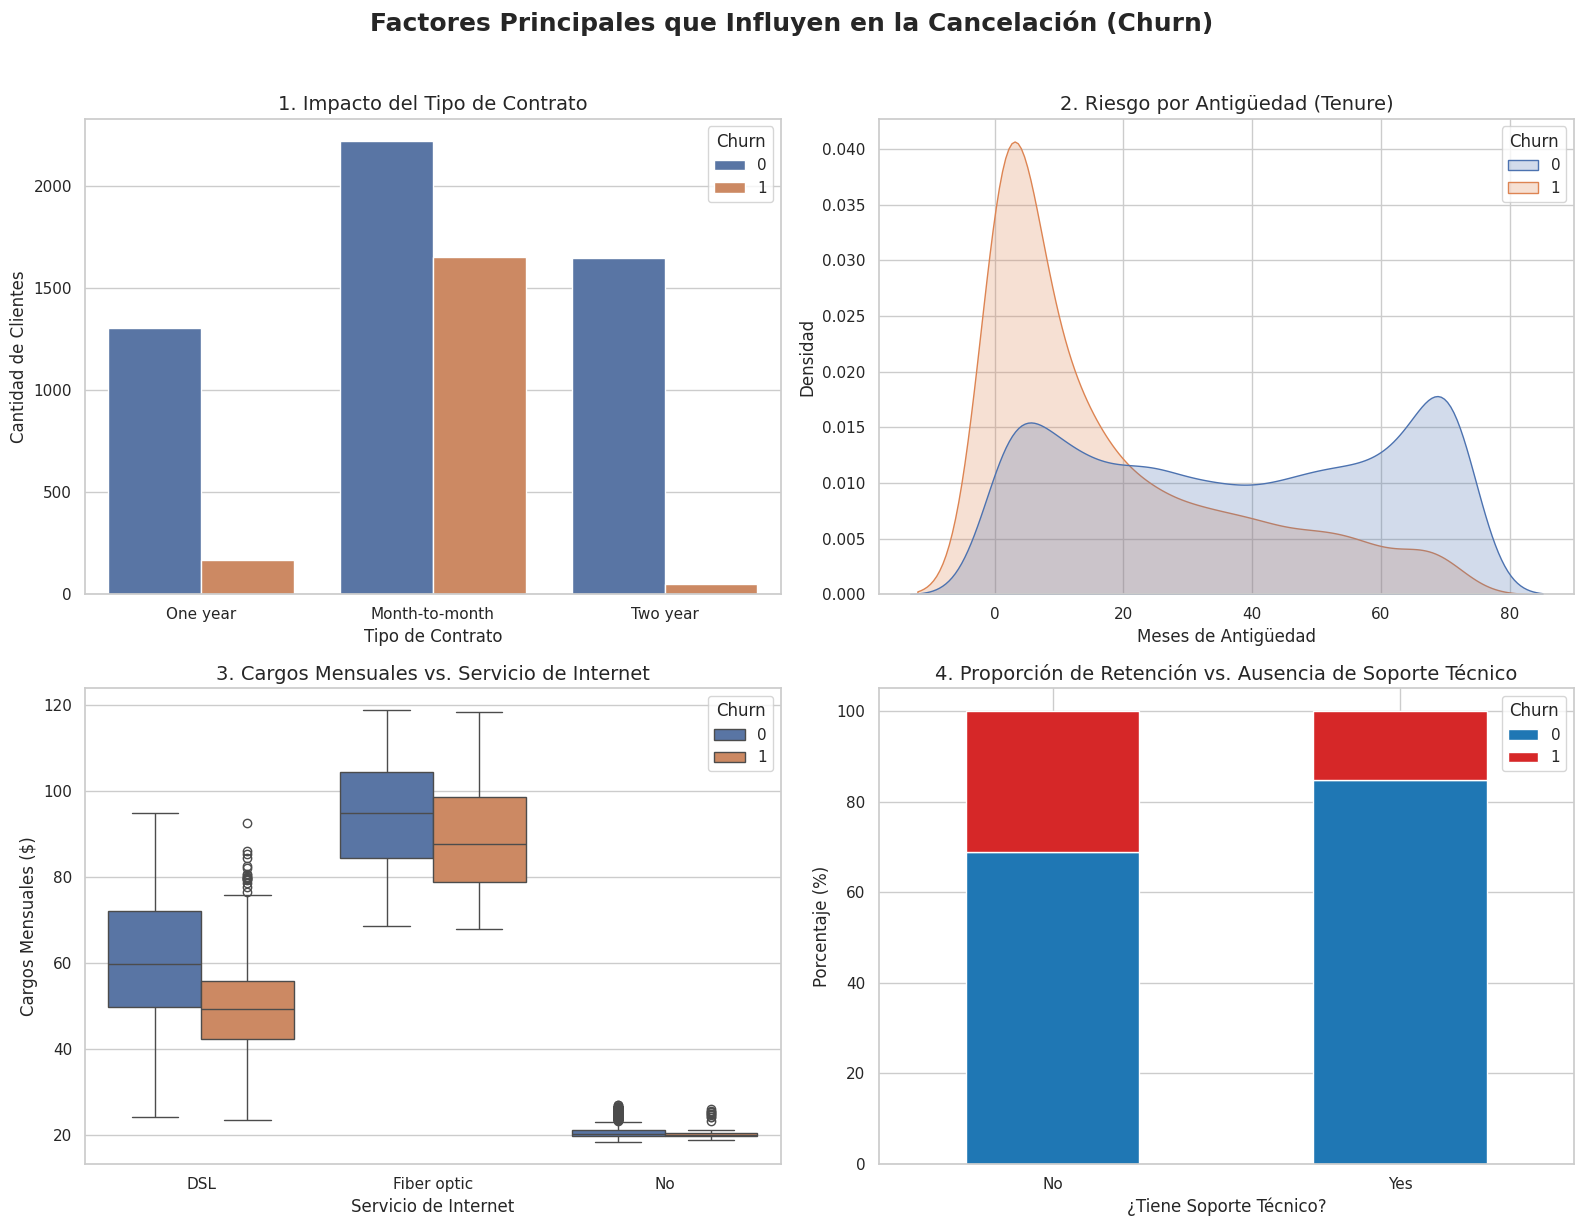

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuramos el estilo visual de los gráficos
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Factores Principales que Influyen en la Cancelación (Churn)', fontsize=18, fontweight='bold', y=1.02)

# 1. El tipo de contrato (Barras apiladas o agrupadas)
sns.countplot(data=df, x='Contract', hue='Churn', ax=axes[0, 0])
axes[0, 0].set_title('1. Impacto del Tipo de Contrato', fontsize=14)
axes[0, 0].set_xlabel('Tipo de Contrato')
axes[0, 0].set_ylabel('Cantidad de Clientes')

# 2. Antigüedad / Tenure (Distribución - KDE Plot)
# Muestra cómo se concentra el abandono en los primeros meses
sns.kdeplot(data=df, x='Tenure', hue='Churn', fill=True, ax=axes[0, 1], common_norm=False)
axes[0, 1].set_title('2. Riesgo por Antigüedad (Tenure)', fontsize=14)
axes[0, 1].set_xlabel('Meses de Antigüedad')
axes[0, 1].set_ylabel('Densidad')

# 3. Tipo de Internet y Cargos Mensuales (Boxplot)
# Muestra la mediana de cargos por tipo de servicio y si cancelaron o no
sns.boxplot(data=df, x='InternetService', y='ChargesMonthly', hue='Churn', ax=axes[1, 0])
axes[1, 0].set_title('3. Cargos Mensuales vs. Servicio de Internet', fontsize=14)
axes[1, 0].set_xlabel('Servicio de Internet')
axes[1, 0].set_ylabel('Cargos Mensuales ($)')

# 4. Soporte Técnico (Proporciones)
# Para mostrar porcentaje, calculamos la tasa de churn por categoría
churn_tech = df.groupby('TechSupport')['Churn'].value_counts(normalize=True).unstack() * 100
churn_tech.plot(kind='bar', stacked=True, color=["#1f77b4", "#d62728"], ax=axes[1, 1])
axes[1, 1].set_title('4. Proporción de Retención vs. Ausencia de Soporte Técnico', fontsize=14)
axes[1, 1].set_xlabel('¿Tiene Soporte Técnico?')
axes[1, 1].set_ylabel('Porcentaje (%)')
axes[1, 1].legend(title='Churn', loc='upper right')
axes[1, 1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()